Dataset Loaded Successfully

First 5 Rows:
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                

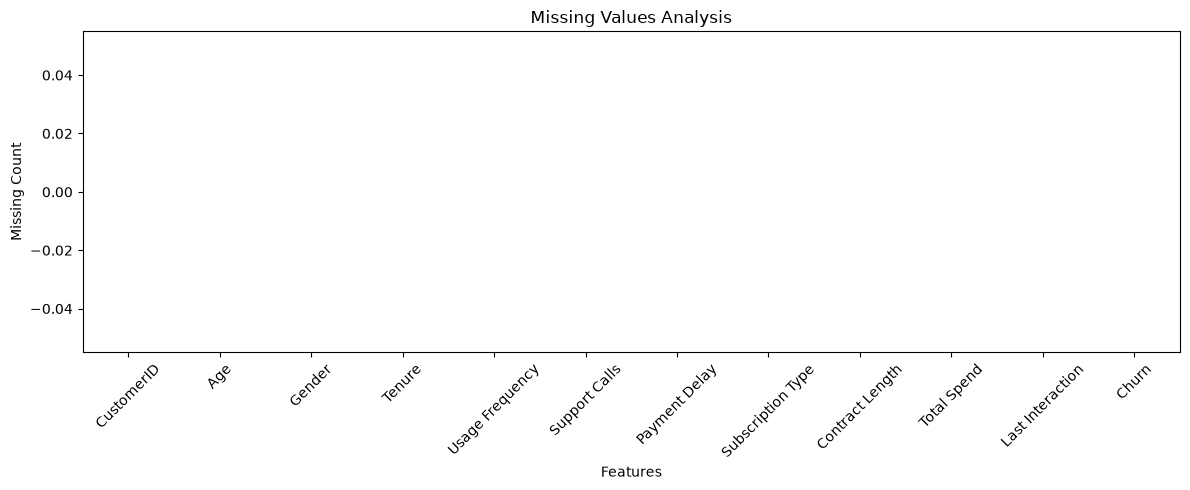


Duplicate Records: 0
CustomerID removed

Encoded Dataset:
   Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0   22       0      25               14              4             27   
1   41       0      28               28              7             13   
2   47       1      27               10              2             29   
3   35       1       9               12              5             17   
4   53       0      58               24              9              2   

   Subscription Type  Contract Length  Total Spend  Last Interaction  Churn  
0                  0                1          598                 9      1  
1                  2                1          584                20      0  
2                  1                0          757                21      0  
3                  1                2          232                18      0  
4                  2                0          533                18      0  

Training Data Shape: (51499, 10)


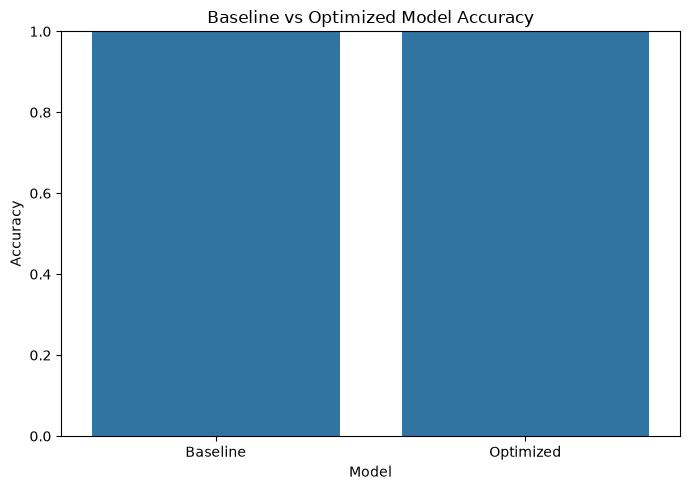

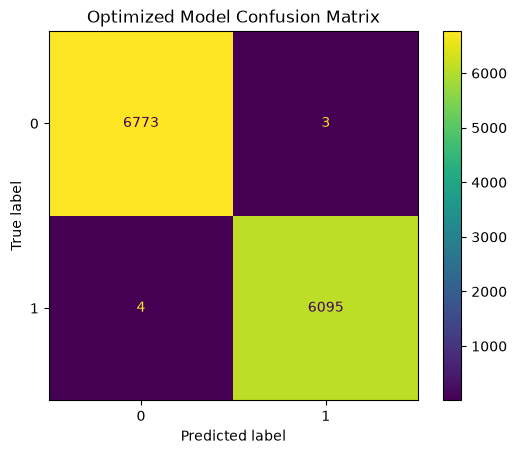

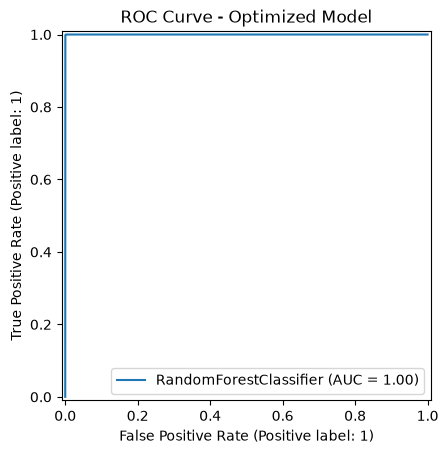


Feature Importance:
             Feature  Importance
5      Payment Delay    0.440150
4      Support Calls    0.159570
2             Tenure    0.109355
3    Usage Frequency    0.085013
1             Gender    0.073621
8        Total Spend    0.041565
7    Contract Length    0.041474
0                Age    0.039558
9   Last Interaction    0.006514
6  Subscription Type    0.003180


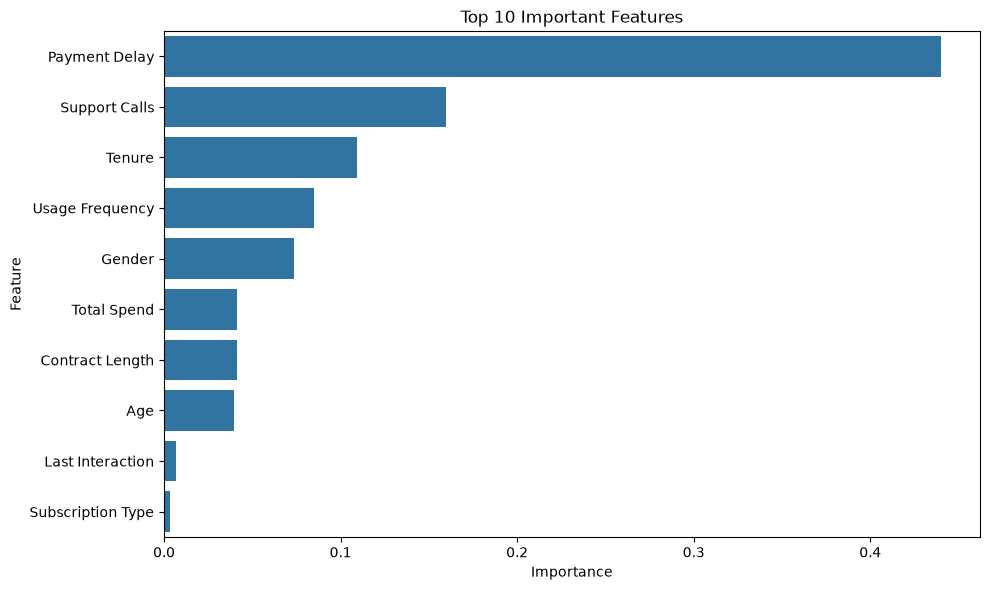


FINAL RESULTS
       Model  Accuracy  Precision    Recall  F1 Score
0   Baseline  0.998990   0.999344  0.998524  0.998934
1  Optimized  0.999456   0.999508  0.999344  0.999426

Optimization Completed Successfully!


In [1]:
# ==========================================================
# Customer Churn Prediction using Model Optimization
# Epochs '26 - Assignment 8
#
# Name: Krish J
# MUID: Krish@mulearn
# ==========================================================


# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Machine Learning Libraries

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)



# ==========================================================
# Load Dataset
# ==========================================================


df = pd.read_csv("customer_churn_dataset.csv")


print("Dataset Loaded Successfully")

print("\nFirst 5 Rows:")
print(df.head())



# ==========================================================
# Dataset Information
# ==========================================================


print("\nDataset Information:")
print(df.info())


print("\nStatistical Summary:")
print(df.describe())



# ==========================================================
# Missing Value Analysis
# ==========================================================


print("\nMissing Values:")
print(df.isnull().sum())


plt.figure(figsize=(12,5))

df.isnull().sum().plot(kind="bar")

plt.title("Missing Values Analysis")

plt.xlabel("Features")

plt.ylabel("Missing Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/missing_values.png",
    dpi=300
)

plt.show()



# ==========================================================
# Duplicate Removal
# ==========================================================


duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)


df.drop_duplicates(inplace=True)



# ==========================================================
# Removing Unnecessary Columns
# ==========================================================


if "CustomerID" in df.columns:

    df.drop(
        "CustomerID",
        axis=1,
        inplace=True
    )

    print("CustomerID removed")



# ==========================================================
# Handling Missing Values
# ==========================================================


for column in df.columns:

    if df[column].dtype == "object":

        df[column].fillna(
            df[column].mode()[0],
            inplace=True
        )

    else:

        df[column].fillna(
            df[column].median(),
            inplace=True
        )



# ==========================================================
# Encoding Categorical Variables
# ==========================================================


encoder = LabelEncoder()


for column in df.select_dtypes(
        include="object").columns:

    df[column] = encoder.fit_transform(
        df[column]
    )


print("\nEncoded Dataset:")
print(df.head())



# ==========================================================
# Feature and Target Separation
# ==========================================================


X = df.drop(
    "Churn",
    axis=1
)


y = df["Churn"]



# ==========================================================
# Train Test Split
# ==========================================================


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)


print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)




# ==========================================================
# BASELINE MODEL
# ==========================================================


print("\n==============================")
print("Baseline Random Forest Model")
print("==============================")


baseline_model = RandomForestClassifier(
    random_state=42
)


baseline_model.fit(
    X_train,
    y_train
)



baseline_prediction = baseline_model.predict(
    X_test
)



baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)


baseline_precision = precision_score(
    y_test,
    baseline_prediction
)


baseline_recall = recall_score(
    y_test,
    baseline_prediction
)


baseline_f1 = f1_score(
    y_test,
    baseline_prediction
)



print("\nBaseline Accuracy:",
      baseline_accuracy)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        baseline_prediction
    )
)




# ==========================================================
# MODEL OPTIMIZATION USING GRIDSEARCHCV
# ==========================================================


print("\n==============================")
print("Hyperparameter Optimization")
print("==============================")


parameter_grid = {


    "n_estimators":
        [100,200,300],


    "max_depth":
        [None,10,20],


    "min_samples_split":
        [2,5,10],


    "min_samples_leaf":
        [1,2,4]

}



grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=parameter_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)



grid_search.fit(
    X_train,
    y_train
)



print("\nBest Parameters:")

print(
    grid_search.best_params_
)




# ==========================================================
# OPTIMIZED MODEL
# ==========================================================


optimized_model = grid_search.best_estimator_



optimized_prediction = optimized_model.predict(
    X_test
)



optimized_accuracy = accuracy_score(
    y_test,
    optimized_prediction
)


optimized_precision = precision_score(
    y_test,
    optimized_prediction
)


optimized_recall = recall_score(
    y_test,
    optimized_prediction
)


optimized_f1 = f1_score(
    y_test,
    optimized_prediction
)



# ==========================================================
# Model Comparison
# ==========================================================


comparison = pd.DataFrame({

    "Model":
    [
        "Baseline",
        "Optimized"
    ],


    "Accuracy":
    [
        baseline_accuracy,
        optimized_accuracy
    ],


    "Precision":
    [
        baseline_precision,
        optimized_precision
    ],


    "Recall":
    [
        baseline_recall,
        optimized_recall
    ],


    "F1 Score":
    [
        baseline_f1,
        optimized_f1
    ]

})


print("\nModel Comparison:")

print(comparison)



# ==========================================================
# Baseline vs Optimized Visualization
# ==========================================================


plt.figure(figsize=(7,5))


sns.barplot(

    x="Model",

    y="Accuracy",

    data=comparison

)


plt.title(
    "Baseline vs Optimized Model Accuracy"
)


plt.ylim(
    0,
    1
)


plt.tight_layout()


plt.savefig(
    "images/baseline_vs_optimized.png",
    dpi=300
)


plt.show()




# ==========================================================
# Confusion Matrix
# ==========================================================


cm = confusion_matrix(

    y_test,

    optimized_prediction

)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)


display.plot()


plt.title(
    "Optimized Model Confusion Matrix"
)


plt.savefig(
    "images/confusion_matrix.png",
    dpi=300
)


plt.show()




# ==========================================================
# ROC Curve
# ==========================================================


RocCurveDisplay.from_estimator(

    optimized_model,

    X_test,

    y_test

)


plt.title(
    "ROC Curve - Optimized Model"
)


plt.savefig(
    "images/roc_curve.png",
    dpi=300
)


plt.show()




# ==========================================================
# Feature Importance Analysis
# ==========================================================


feature_importance = pd.DataFrame({

    "Feature":
    X.columns,


    "Importance":
    optimized_model.feature_importances_

})


feature_importance.sort_values(

    by="Importance",

    ascending=False,

    inplace=True

)


print("\nFeature Importance:")

print(feature_importance)



plt.figure(figsize=(10,6))


sns.barplot(

    x="Importance",

    y="Feature",

    data=feature_importance.head(10)

)


plt.title(
    "Top 10 Important Features"
)


plt.tight_layout()


plt.savefig(

    "images/feature_importance.png",

    dpi=300

)


plt.show()



# ==========================================================
# Final Results
# ==========================================================


print("\n==============================")
print("FINAL RESULTS")
print("==============================")


print(
    comparison
)


print("\nOptimization Completed Successfully!")